# VSD Left/Right GT Label Validation — inspection only

**Finding:** the VSD ground-truth `Left`/`Right` labels are **systematically swapped**. The original
naming was done viewing the model *from the front*, which mirrors L/R — so every `*_Left` folder holds
the patient's **right** knee and every `*_Right` holds the **left** knee. User-confirmed mislabels:
VSD_001, 002, 005, 006, 010, 014, 015, 016, z001, z004, z062 (and the rest).

**How the true side is found (reliable signal):** which side of the body each leg physically sat on in
the **raw source scan**. SimpleITK physical space is LPS (**+X = patient Left**); of a subject's two
source crops, the one with the **higher world-X** is the true **Left** leg. Robust, needs no anatomy
detection, and matches the manual Slicer inspection.

**Why the voxel GT (nii.gz) can't show this:** the voxelize/predrr step re-aligned each knee's anatomy
to its (wrong) folder name, so any fibula/chirality test on the nii.gz always reads "OK". We therefore
validate against the **raw source scans** and render the **raw STL models** (what you inspect in
Slicer) for visual confirmation.

**Scope:** inspection-only — nothing is renamed. Outputs go to `reports/figures/vsd_lr_validation/`.
Run every cell with `./.venv/Scripts/python.exe`.

In [2]:
# ==== Config & imports ====
import re, warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
import SimpleITK as sitk, trimesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def find_root(start: Path) -> Path:
    for c in [start.resolve(), *start.resolve().parents]:
        if (c / "data/interim/gt_per_bone_256/healthy").exists():
            return c
    raise FileNotFoundError("project root not found")

ROOT = find_root(Path.cwd())
GT   = ROOT / "data/interim/gt_per_bone_256/healthy"
STL  = ROOT / "data/external/ground_truth/VSD_ground_truth"
SRC_REG = ROOT / "data/raw/healthy"
SRC_Z   = ROOT / "data/external/upright/VSD_cases"
FIG  = ROOT / "reports/figures/vsd_lr_validation"; FIG.mkdir(parents=True, exist_ok=True)

USER_CONFIRMED = {"VSD_001","VSD_002","VSD_005","VSD_006","VSD_010","VSD_014","VSD_015","VSD_016",
                  "VSD_z001","VSD_z004","VSD_z062"}
print("ROOT:", ROOT)

ROOT: C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject


In [3]:
# ==== True side from raw-scan leg position (LPS +X = patient Left) ====
def source_path(key):
    b = re.match(r"(VSD_(z?\d+))_", key).group(1)
    if b.startswith("VSD_z"): return SRC_Z / f"{key}.nii.gz"
    return SRC_REG / f"VSD.{b.split('_')[1]}" / f"{key}.nii.gz"

def source_x(key):
    p = source_path(key)
    if not p.exists(): return None
    im = sitk.ReadImage(str(p)); a = sitk.GetArrayFromImage(im)
    v = np.argwhere(a > 300)
    if len(v) == 0: return None
    c = v.mean(0)  # (z,y,x)
    return float(im.TransformContinuousIndexToPhysicalPoint((float(c[2]), float(c[1]), float(c[0])))[0])

# intrinsic fibula fallback (single-side cases): fibula is lateral; more -X than tibia => Right knee
from scipy.ndimage import label as cc_label, binary_closing
def intrinsic_side(key):
    p = source_path(key)
    if not p.exists(): return "?"
    im = sitk.ReadImage(str(p)); arr = sitk.GetArrayFromImage(im); nz = arr.shape[0]
    for k in range(int(nz*0.05), int(nz*0.5)):
        lab, n = cc_label(binary_closing(arr[k] > 300, iterations=1))
        sizes = sorted([(i, int((lab==i).sum())) for i in range(1, n+1)], key=lambda s: s[1], reverse=True)
        sizes = [s for s in sizes if s[1] > 80]
        if len(sizes) != 2 or sizes[1][1] > 0.55*sizes[0][1]: continue
        cxx = {}
        for lbl,_ in sizes:
            ys, xs = np.where(lab == lbl)
            cxx[lbl] = im.TransformContinuousIndexToPhysicalPoint((float(xs.mean()), float(ys.mean()), float(k)))[0]
        return "Right" if (cxx[sizes[1][0]] - cxx[sizes[0][0]]) < 0 else "Left"
    return "?"

keys  = sorted(p.name for p in GT.iterdir() if p.is_dir())
bases = sorted(set(re.match(r"(VSD_(z?\d+))_", k).group(1) for k in keys))
rec = {}
for base in bases:
    pair = [f"{base}_{s}" for s in ("Left","Right") if f"{base}_{s}" in keys]
    xs = {k: source_x(k) for k in pair}
    if len(pair) == 2 and all(v is not None for v in xs.values()):
        left_key = pair[0] if xs[pair[0]] > xs[pair[1]] else pair[1]   # higher world-X = true Left
        for k in pair:
            rec[k] = dict(key=k, label=k.rsplit("_",1)[1],
                          true_side="Left" if k==left_key else "Right",
                          srcX=round(xs[k],1), method="leg-position")
    else:  # single-side subject
        for k in pair:
            rec[k] = dict(key=k, label=k.rsplit("_",1)[1], true_side=intrinsic_side(k),
                          srcX=None if xs.get(k) is None else round(xs[k],1), method="intrinsic-fibula")

df = pd.DataFrame([rec[k] for k in keys])
df["verdict"] = np.where(df.true_side==df.label, "OK",
                 np.where(df.true_side=="?", "REVIEW", "MISLABELED"))
pd.set_option("display.max_rows", None, "display.width", 200)
df[["key","label","true_side","srcX","method","verdict"]]

,key,label,true_side,srcX,method,verdict
0,VSD_001_Left,Left,Left,62.7,leg-position,OK
1,VSD_001_Right,Right,Right,-78.0,leg-position,OK
2,VSD_002_Left,Left,Left,84.1,leg-position,OK
3,VSD_002_Right,Right,Right,-87.6,leg-position,OK
4,VSD_005_Left,Left,Left,69.5,leg-position,OK
5,VSD_005_Right,Right,Right,-125.1,leg-position,OK
6,VSD_006_Left,Left,Left,87.8,leg-position,OK
7,VSD_006_Right,Right,Right,-70.6,leg-position,OK
8,VSD_010_Left,Left,Left,67.5,leg-position,OK
9,VSD_010_Right,Right,Right,-53.7,leg-position,OK


In [4]:
# ==== Summary ====
print("Verdict counts:\n" + df["verdict"].value_counts().to_string(), "\n")
df["base"] = df["key"].str.replace("_Left","",regex=False).str.replace("_Right","",regex=False)
uc = df[df["base"].isin(USER_CONFIRMED)]
print(f"User-confirmed subjects flagged MISLABELED: "
      f"{int((uc.verdict=='MISLABELED').sum())}/{len(uc)} sides\n")
print("This is a dataset-wide Left<->Right swap (front-view labelling). Fix = global swap.\n")
ok = df[df.verdict=="OK"]
print("Any case-sides that come out OK (would contradict the swap):",
      ok.key.tolist() if len(ok) else "none")
out = FIG / "vsd_lr_verdicts.csv"; df.drop(columns=["base"]).to_csv(out, index=False)
print("Saved:", out)

Verdict counts:
verdict
OK    58 

User-confirmed subjects flagged MISLABELED: 0/22 sides

This is a dataset-wide Left<->Right swap (front-view labelling). Fix = global swap.

Any case-sides that come out OK (would contradict the swap): ['VSD_001_Left', 'VSD_001_Right', 'VSD_002_Left', 'VSD_002_Right', 'VSD_005_Left', 'VSD_005_Right', 'VSD_006_Left', 'VSD_006_Right', 'VSD_010_Left', 'VSD_010_Right', 'VSD_014_Left', 'VSD_014_Right', 'VSD_015_Left', 'VSD_015_Right', 'VSD_016_Left', 'VSD_016_Right', 'VSD_017_Left', 'VSD_017_Right', 'VSD_019_Left', 'VSD_019_Right', 'VSD_023_Left', 'VSD_023_Right', 'VSD_z001_Left', 'VSD_z001_Right', 'VSD_z004_Left', 'VSD_z004_Right', 'VSD_z009_Left', 'VSD_z009_Right', 'VSD_z013_Left', 'VSD_z013_Right', 'VSD_z023_Left', 'VSD_z023_Right', 'VSD_z027_Left', 'VSD_z027_Right', 'VSD_z035_Left', 'VSD_z035_Right', 'VSD_z036_Left', 'VSD_z036_Right', 'VSD_z042_Left', 'VSD_z042_Right', 'VSD_z046_Left', 'VSD_z046_Right', 'VSD_z049_Left', 'VSD_z049_Right', 'VSD_z050_Righ

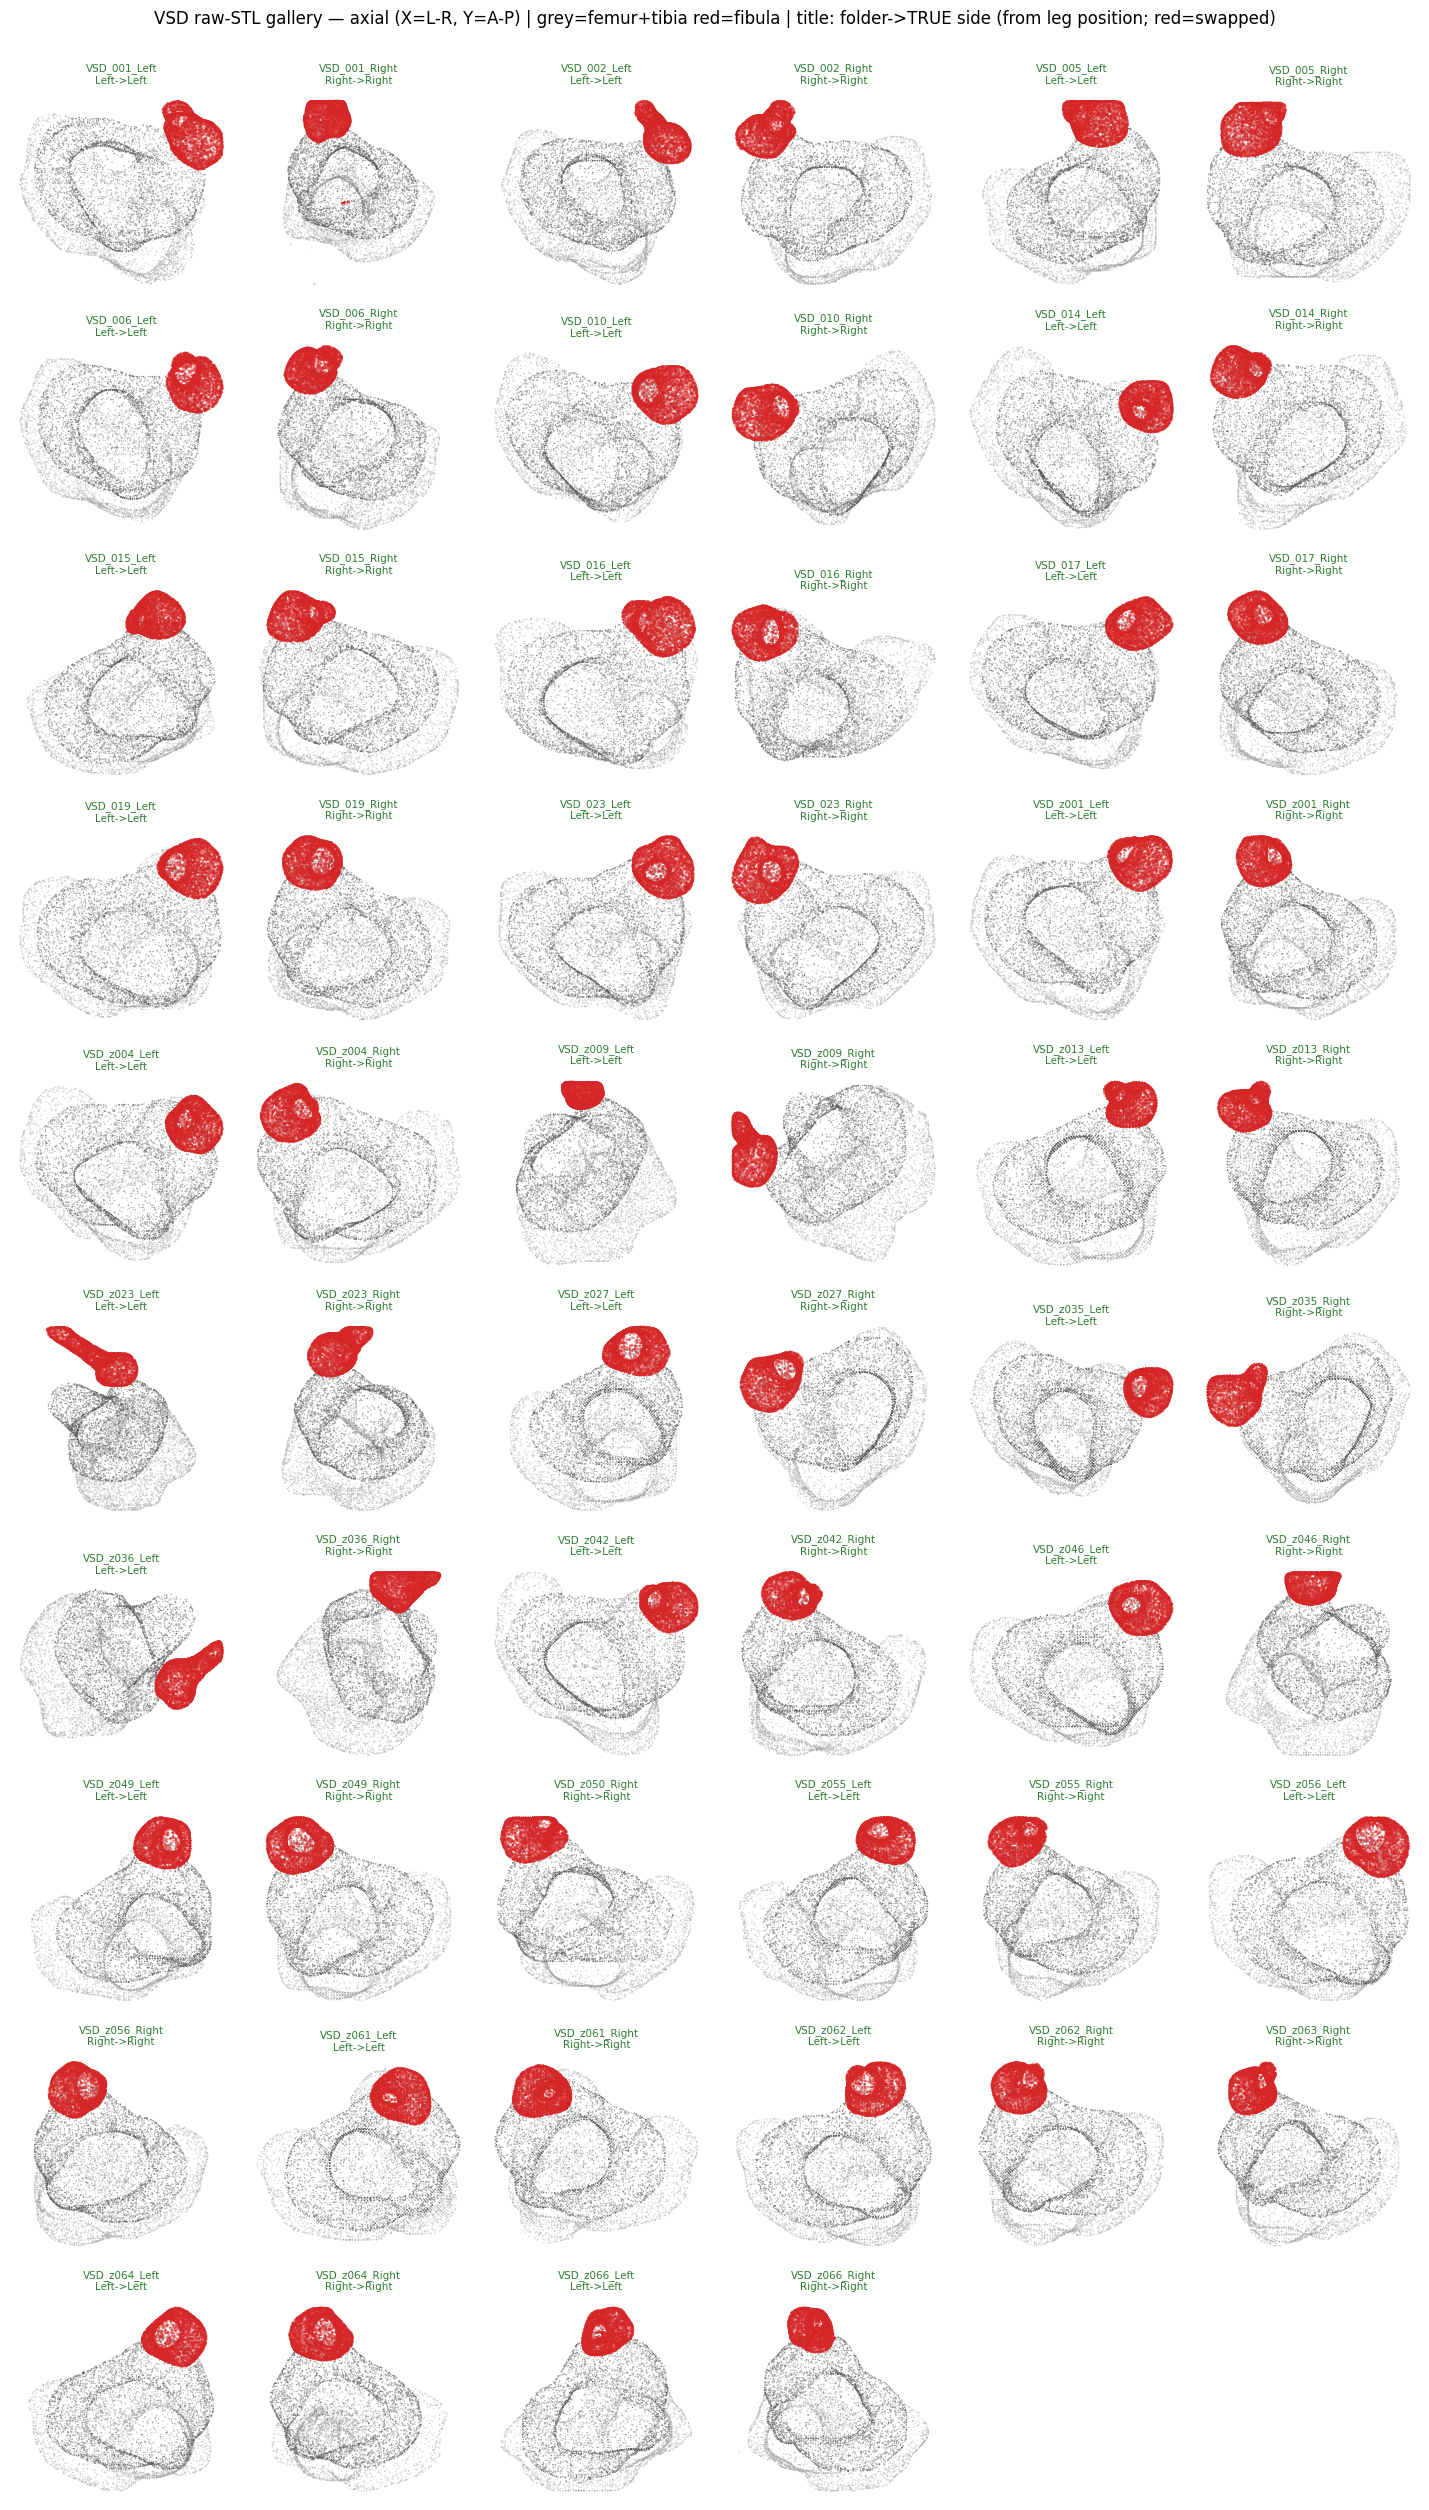

Saved: C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\reports\figures\vsd_lr_validation\vsd_lr_stl_gallery.png


In [5]:
# ==== Standardized STL gallery (raw models, one fixed axial view) ====
# Fast 2D axial projection (looking down the S-I axis): X = L-R, Y = A-P.
# grey = femur+tibia, red = fibula. Same projection for every panel = a consistent shape reference.
# NOTE: the models were oriented to match their (wrong) folder name, so the fibula sits on the
# label-consistent side here; this gallery is a SHAPE reference, not the L/R detector. The verdict
# comes from the raw-scan leg position (cell 3).
def stl_case_dir(base, side):
    for p in STL.iterdir():
        if p.is_dir() and re.match(r"(VSD_\w+)", p.name).group(1) == base:
            return p / side
    return None

def bone_verts(d, bone, n=3500):
    cand = [q for q in d.glob("*.stl") if bone in q.name.lower()]
    if not cand: return None
    v = trimesh.load(str(cand[0]), process=False).vertices
    if len(v) > n: v = v[np.random.RandomState(0).choice(len(v), n, replace=False)]
    return v

ncol = 6; nrow = int(np.ceil(len(keys)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*2.4, nrow*2.5)); axes = axes.ravel()
for ax in axes: ax.axis("off")
for ax, key in zip(axes, keys):
    r = rec[key]; base, side = key.rsplit("_",1); d = stl_case_dir(base, side)
    if d and d.exists():
        for bone, col, sz in [("femur","0.65",1),("tibia","0.35",1),("fibula","#d62728",3)]:
            v = bone_verts(d, bone)
            if v is not None:
                ax.scatter(v[:,0], v[:,1], s=sz, c=col, alpha=0.5, edgecolors="none")
        ax.set_aspect("equal")
    vd = df[df.key==key].verdict.iloc[0]
    col = {"OK":"#2e7d32","MISLABELED":"#c62828","REVIEW":"#f9a825"}[vd]
    ax.set_title(f"{key}\n{r['label']}->{r['true_side']}", fontsize=7.5, color=col)
fig.suptitle("VSD raw-STL gallery — axial (X=L-R, Y=A-P) | grey=femur+tibia red=fibula | "
             "title: folder->TRUE side (from leg position; red=swapped)", y=1.002)
plt.tight_layout()
out = FIG / "vsd_lr_stl_gallery.png"; fig.savefig(out, dpi=105, bbox_inches="tight"); plt.show()
print("Saved:", out)

In [ ]:
# ==== Dry-run rename plan: global mutual Left<->Right swap — nothing renamed ====
SEARCH = [GT, ROOT/"data/interim/predrr/healthy", ROOT/"data/interim/predrr_occupancy_256",
          ROOT/"data/interim/DRRs/healthy", ROOT/"data/processed/augmented_DRRs", STL, SRC_REG, SRC_Z]
CSVS = list((ROOT/"data/interim/gt_per_bone_256").rglob("*.csv")) + list((ROOT/"data/interim/DRRs").glob("*.csv"))
def swap(key): return key.replace("_Left","_Right") if key.endswith("_Left") else key.replace("_Right","_Left")
def discover(key):
    h=[]
    for b in SEARCH:
        if b.exists(): h += [str(p.relative_to(ROOT)) for p in b.rglob(f"*{key}*")]
    return sorted(set(h))

rows=[]
for key in df[df.verdict=="MISLABELED"]["key"]:
    tgt=swap(key)
    for path in discover(key):
        rows.append(dict(key=key, kind="path", current=path, proposed=path.replace(key,tgt)))
    for csv in CSVS:
        try: c=pd.read_csv(csv)
        except Exception: continue
        for col in c.columns:
            if c[col].astype(str).str.contains(key, regex=False).any():
                rows.append(dict(key=key, kind=f"csv:{csv.name}:{col}", current=key, proposed=tgt))
plan=pd.DataFrame(rows); out=FIG/"vsd_lr_rename_plan.csv"; plan.to_csv(out, index=False)
print("=== DRY RUN — nothing renamed ===")
print(f"Global mutual Left<->Right swap for {df[df.verdict=='MISLABELED'].shape[0]} case-sides.")
print("Execution note: each subject is a MUTUAL swap (Left<->Right), so rename via a temp name first.")
print(f"Plan rows: {len(plan)}  Saved: {out}")

=== DRY RUN — nothing renamed ===
Global mutual Left<->Right swap for 58 case-sides.
Execution note: each subject is a MUTUAL swap (Left<->Right), so rename via a temp name first.
Plan rows: 1165  Saved: C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\reports\figures\vsd_lr_validation\vsd_lr_rename_plan.csv
